# P2 cross-view FCMAE training across folds

This notebook combines the `fcmae_p2_history_fold*.csv` run histories with the independent frozen-encoder feature audit:

1. **Fold dashboards** — total loss, FCMAE/cross-view components, feature standard deviation, and learning rate.
2. **Cross-fold summary** — convergence consistency, checkpoint timing, improvement, and final feature spread.
3. **Feature-audit summary** — direct P1 → P2 evidence for local anatomy, cross-view retrieval, representation diversity, and P2 preservation.

The best checkpoint is the minimum `validation_loss`, matching the P2 training code. Train and validation losses are descriptive rather than an automatic overfitting gap because training uses stochastic masking and augmentation.

## 1. Load and validate all P2 fold histories

The path search works from the repository root or a directory inside it. Result files are read only.

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
HISTORY_PATTERN, ROLLING_WINDOW, FEATURE_STD_MIN = "fcmae_p2_history_fold*.csv", 7, 1e-6
REQUIRED_COLUMNS = {"epoch", "train_loss", "validation_loss", "feature_std", "lr", "train_fcmae", "train_cross"}

def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "TestProject" / "models" / "foundation_stage2_v1").is_dir(): return candidate / "TestProject"
        if (candidate / "models" / "foundation_stage2_v1").is_dir(): return candidate
    raise FileNotFoundError("Could not locate models/foundation_stage2_v1.")

PROJECT_ROOT = find_project_root(Path.cwd())
HISTORY_DIR = PROJECT_ROOT / "models" / "foundation_stage2_v1"
history_files = sorted(HISTORY_DIR.glob(HISTORY_PATTERN))
if not history_files: raise FileNotFoundError(f"No histories matched {HISTORY_DIR / HISTORY_PATTERN}")
frames = []
for path in history_files:
    match = re.search(r"fold(\d+)", path.stem)
    if match is None: raise ValueError(f"Cannot infer fold from {path.name}")
    frame = pd.read_csv(path)
    missing = REQUIRED_COLUMNS - set(frame.columns)
    if missing: raise ValueError(f"{path.name} is missing {sorted(missing)}")
    frame = frame.copy()
    frame[list(REQUIRED_COLUMNS)] = frame[list(REQUIRED_COLUMNS)].apply(pd.to_numeric, errors="raise")
    if frame.empty or frame.epoch.duplicated().any() or not frame.epoch.is_monotonic_increasing: raise ValueError(f"Invalid epoch sequence: {path.name}")
    if not np.isfinite(frame[list(REQUIRED_COLUMNS)].to_numpy()).all(): raise ValueError(f"Non-finite values: {path.name}")
    if not np.allclose(frame.train_loss, frame.train_fcmae + frame.train_cross, rtol=1e-5, atol=1e-7): raise ValueError(f"Loss components do not sum: {path.name}")
    frame["fold"], frame["source_file"] = int(match.group(1)), path.name
    frames.append(frame)
history = pd.concat(frames, ignore_index=True).sort_values(["fold", "epoch"]).reset_index(drop=True)
folds = sorted(history.fold.unique())
colors = dict(zip(folds, plt.cm.tab10(np.linspace(0, 1, len(folds)))))
print(f"Loaded {len(history_files)} P2 histories from {HISTORY_DIR}")
print(f"Folds: {folds} | total rows: {len(history):,}")

Loaded 5 P2 histories from C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\models\foundation_stage2_v1
Folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] | total rows: 500


In [2]:
coverage = history.groupby("fold", as_index=False).agg(first_epoch=("epoch", "min"), last_epoch=("epoch", "max"), rows=("epoch", "size"), source_file=("source_file", "first"))
coverage["continuous_epochs"] = coverage.rows == coverage.last_epoch - coverage.first_epoch + 1
display(coverage)
if not coverage.continuous_epochs.all(): raise ValueError("At least one P2 history has missing epochs.")

,fold,first_epoch,last_epoch,rows,source_file,continuous_epochs
0,0,0,99,100,fcmae_p2_history_fold0.csv,True
1,1,0,99,100,fcmae_p2_history_fold1.csv,True
2,2,0,99,100,fcmae_p2_history_fold2.csv,True
3,3,0,99,100,fcmae_p2_history_fold3.csv,True
4,4,0,99,100,fcmae_p2_history_fold4.csv,True


## 2. Fold-by-fold P2 dashboards

Faint lines are raw values and bold lines are centered rolling means. The dashed line marks the best validation epoch. The component panel shows how P2 divides its training objective between masked FCMAE and cross-view reconstruction.

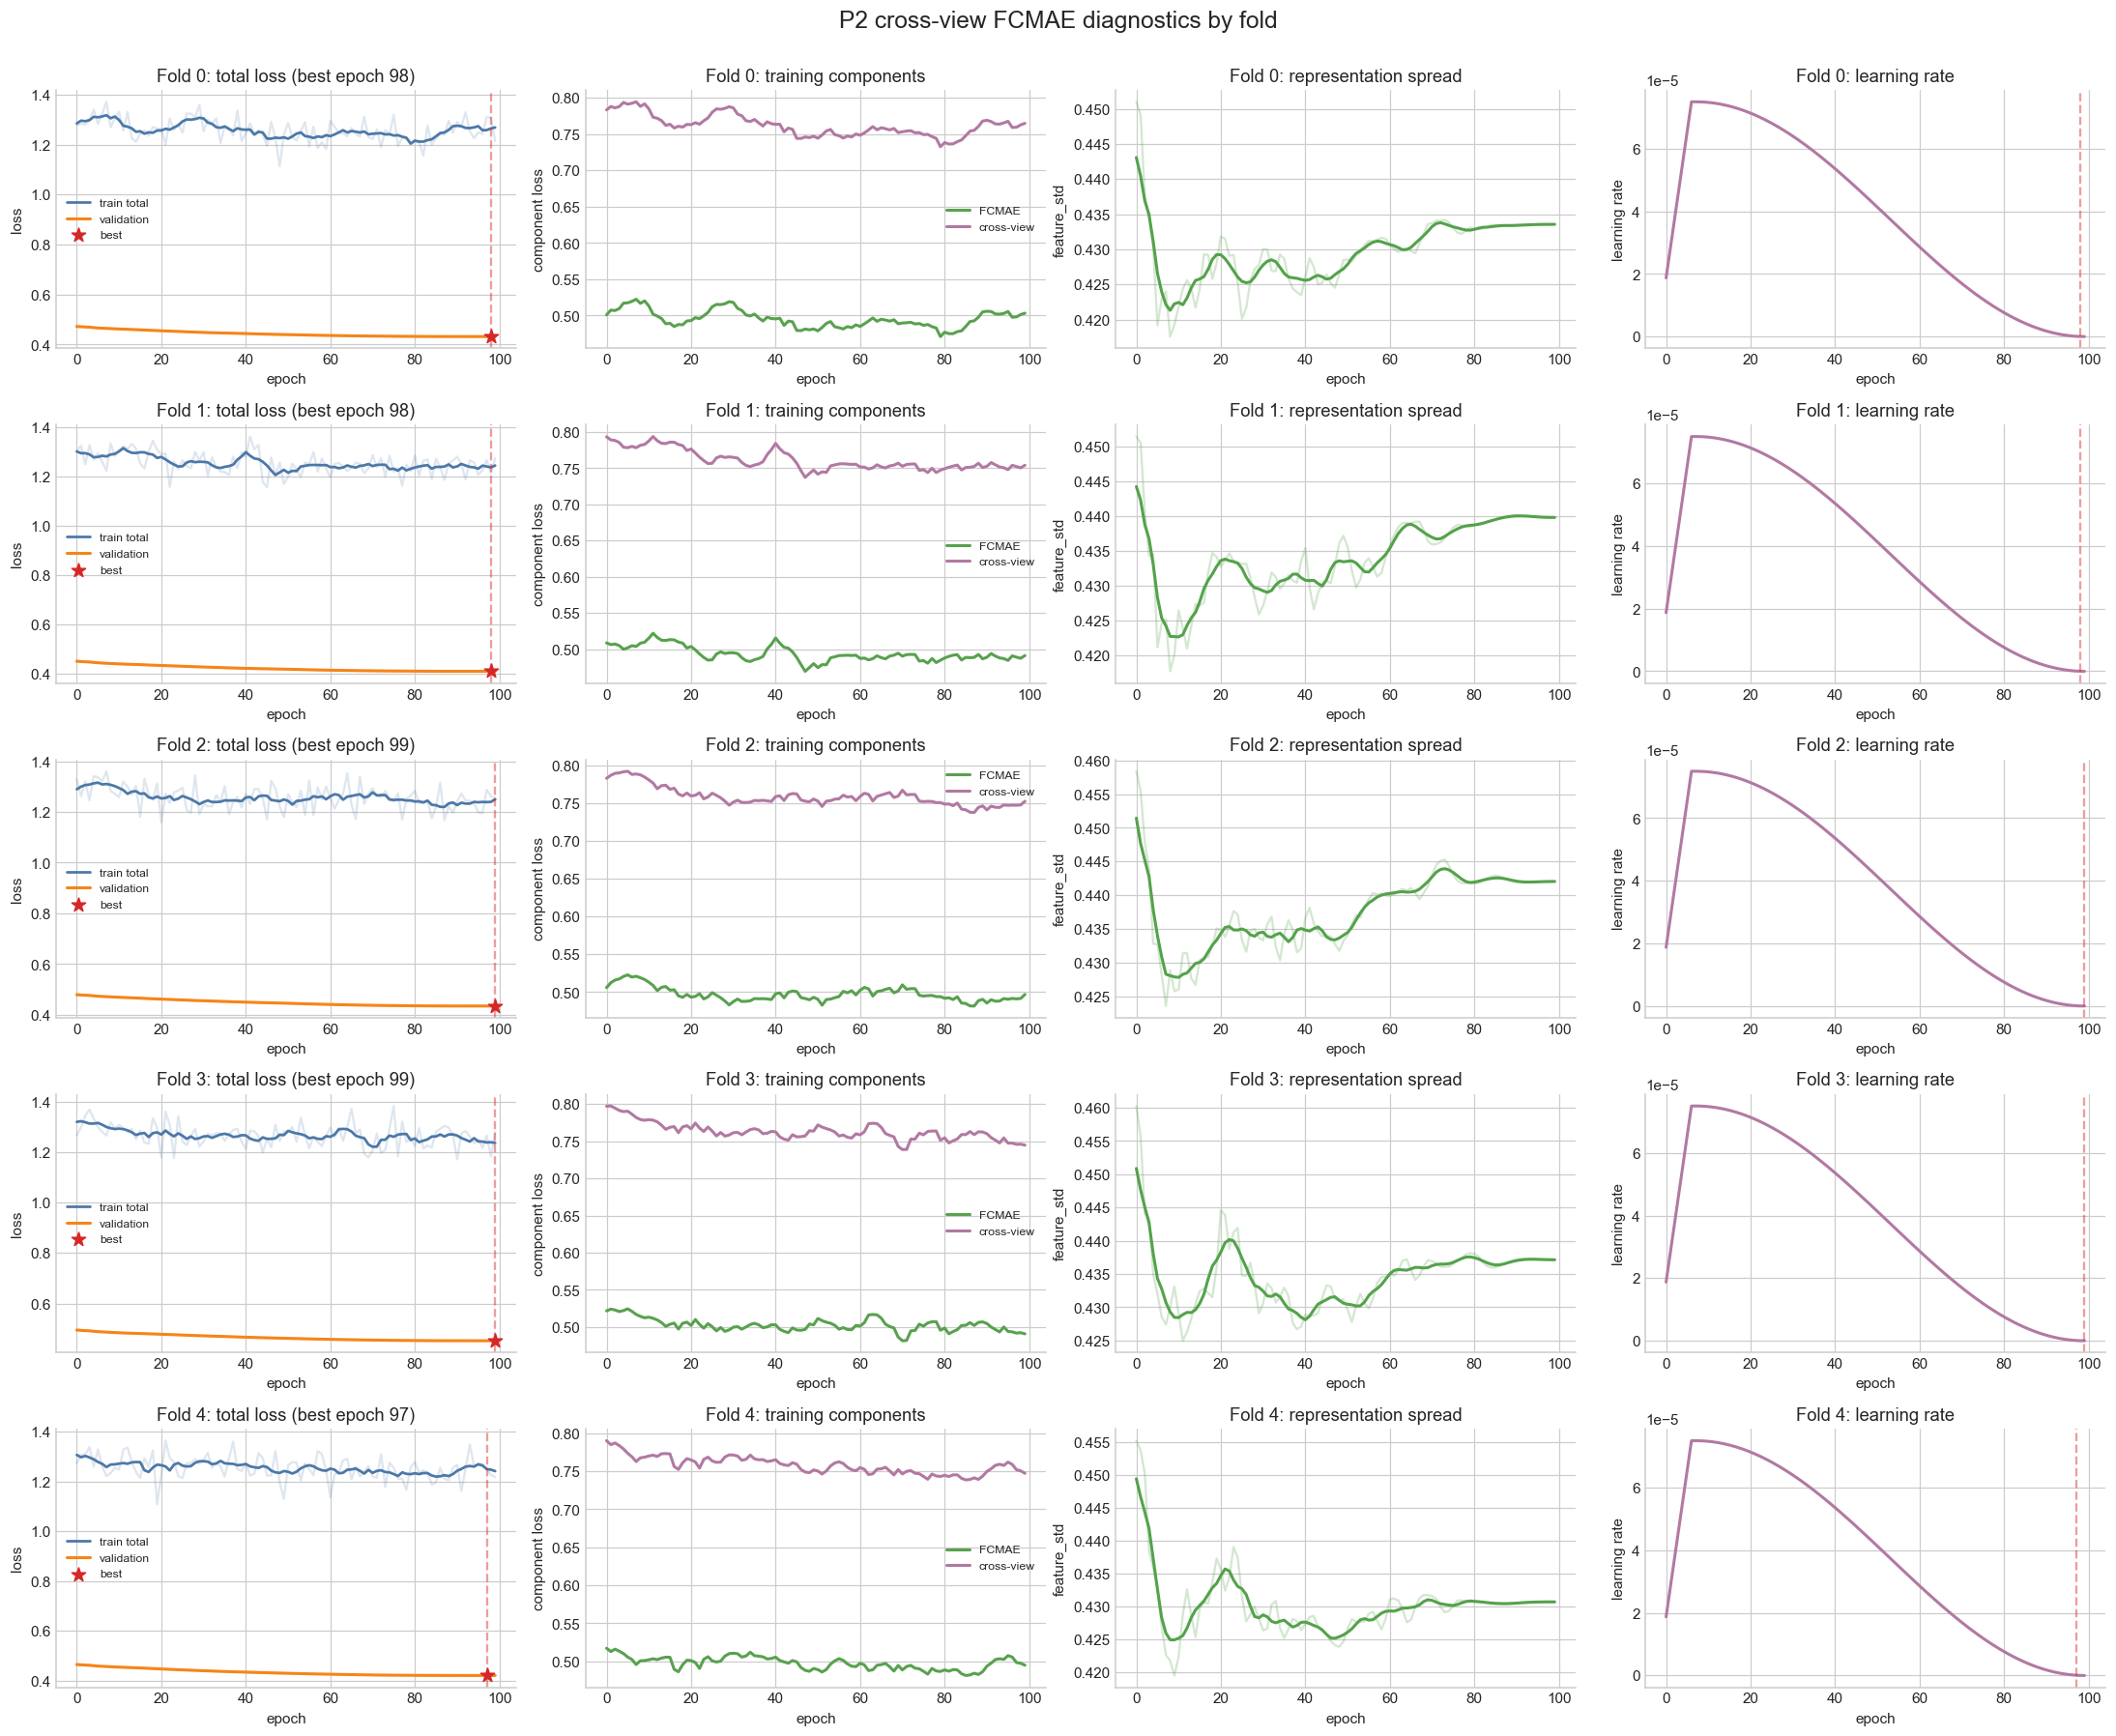

In [3]:
figure, axes = plt.subplots(len(folds), 4, figsize=(20, 3.25 * len(folds)), squeeze=False)
for row, fold in enumerate(folds):
    fold_data = history.query("fold == @fold").copy()
    best = fold_data.loc[fold_data.validation_loss.idxmin()]
    metrics = ["train_loss", "validation_loss", "train_fcmae", "train_cross", "feature_std"]
    smooth = fold_data[metrics].rolling(ROLLING_WINDOW, center=True, min_periods=1).mean()
    loss_axis, component_axis, feature_axis, lr_axis = axes[row]
    loss_axis.plot(fold_data.epoch, fold_data.train_loss, color="#4C78A8", alpha=0.18)
    loss_axis.plot(fold_data.epoch, fold_data.validation_loss, color="#F58518", alpha=0.22)
    loss_axis.plot(fold_data.epoch, smooth.train_loss, color="#4C78A8", linewidth=1.8, label="train total")
    loss_axis.plot(fold_data.epoch, smooth.validation_loss, color="#F58518", linewidth=2, label="validation")
    loss_axis.scatter(best.epoch, best.validation_loss, color="#D62728", marker="*", s=95, zorder=5, label="best")
    loss_axis.axvline(best.epoch, color="#D62728", linestyle="--", alpha=0.45)
    loss_axis.set(title=f"Fold {fold}: total loss (best epoch {int(best.epoch)})", xlabel="epoch", ylabel="loss")
    loss_axis.legend(fontsize=8)
    component_axis.plot(fold_data.epoch, smooth.train_fcmae, color="#59A14F", linewidth=2, label="FCMAE")
    component_axis.plot(fold_data.epoch, smooth.train_cross, color="#B279A2", linewidth=2, label="cross-view")
    component_axis.set(title=f"Fold {fold}: training components", xlabel="epoch", ylabel="component loss")
    component_axis.legend(fontsize=8)
    feature_axis.plot(fold_data.epoch, fold_data.feature_std, color="#54A24B", alpha=0.25)
    feature_axis.plot(fold_data.epoch, smooth.feature_std, color="#54A24B", linewidth=2)
    feature_axis.set(title=f"Fold {fold}: representation spread", xlabel="epoch", ylabel="feature_std")
    lr_axis.plot(fold_data.epoch, fold_data.lr, color="#B279A2", linewidth=2)
    lr_axis.axvline(best.epoch, color="#D62728", linestyle="--", alpha=0.45)
    lr_axis.set(title=f"Fold {fold}: learning rate", xlabel="epoch", ylabel="learning rate")
    lr_axis.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))
figure.suptitle("P2 cross-view FCMAE diagnostics by fold", fontsize=16, y=1.002)
figure.tight_layout()
plt.show()

## 3. Per-fold numerical summary

`improvement_pct` is the decrease from epoch 0 to the best validation loss. `cross_share_pct` is the average share of total training loss contributed by cross-view reconstruction.

In [4]:
summary_rows = []
for fold, fold_data in history.groupby("fold", sort=True):
    fold_data = fold_data.sort_values("epoch")
    best = fold_data.loc[fold_data.validation_loss.idxmin()]
    initial, final = fold_data.iloc[0], fold_data.iloc[-1]
    summary_rows.append({
        "fold": int(fold), "epochs": len(fold_data), "initial_val_loss": initial.validation_loss,
        "best_val_loss": best.validation_loss, "best_epoch": int(best.epoch), "final_val_loss": final.validation_loss,
        "improvement_pct": 100*(initial.validation_loss-best.validation_loss)/initial.validation_loss,
        "final_vs_best_pct": 100*(final.validation_loss-best.validation_loss)/best.validation_loss,
        "epochs_after_best": int(final.epoch-best.epoch),
        "mean_train_fcmae": fold_data.train_fcmae.mean(), "mean_train_cross": fold_data.train_cross.mean(),
        "cross_share_pct": 100*(fold_data.train_cross/fold_data.train_loss).mean(),
        "min_feature_std": fold_data.feature_std.min(), "feature_std_at_best": best.feature_std,
        "final_feature_std": final.feature_std, "peak_lr": fold_data.lr.max(),
        "peak_lr_epoch": int(fold_data.loc[fold_data.lr.idxmax(), "epoch"]),
    })
summary = pd.DataFrame(summary_rows).set_index("fold")
display(summary.style.format({
    "initial_val_loss": "{:.5f}", "best_val_loss": "{:.5f}", "final_val_loss": "{:.5f}",
    "improvement_pct": "{:.1f}%", "final_vs_best_pct": "{:.3f}%",
    "mean_train_fcmae": "{:.4f}", "mean_train_cross": "{:.4f}", "cross_share_pct": "{:.1f}%",
    "min_feature_std": "{:.4f}", "feature_std_at_best": "{:.4f}", "final_feature_std": "{:.4f}", "peak_lr": "{:.2e}",
}).background_gradient(subset=["best_val_loss"], cmap="RdYlGn_r"))

,epochs,initial_val_loss,best_val_loss,best_epoch,final_val_loss,improvement_pct,final_vs_best_pct,epochs_after_best,mean_train_fcmae,mean_train_cross,cross_share_pct,min_feature_std,feature_std_at_best,final_feature_std,peak_lr,peak_lr_epoch
fold,,,,,,,,,,,,,,,,
0,100,0.47800,0.43192,98,0.43193,9.6%,0.001%,1,0.4953,0.7621,60.6%,0.4176,0.4336,0.4336,7.50e-05,6
1,100,0.45560,0.40976,98,0.40977,10.1%,0.000%,1,0.4936,0.7614,60.7%,0.4177,0.4398,0.4398,7.50e-05,6
2,100,0.48462,0.43487,99,0.43487,10.3%,0.000%,0,0.4974,0.7593,60.4%,0.4236,0.4421,0.4421,7.50e-05,6
3,100,0.49968,0.45242,99,0.45242,9.5%,0.000%,0,0.5026,0.7632,60.3%,0.4250,0.4371,0.4371,7.50e-05,6
4,100,0.46933,0.42004,97,0.42004,10.5%,0.000%,2,0.4975,0.7578,60.4%,0.4195,0.4307,0.4307,7.50e-05,6


### Final feature standard deviation by fold

The y-axis starts at zero. The collapse threshold (`1e-6`) is reported in the caption because plotting it directly would compress the fold differences.

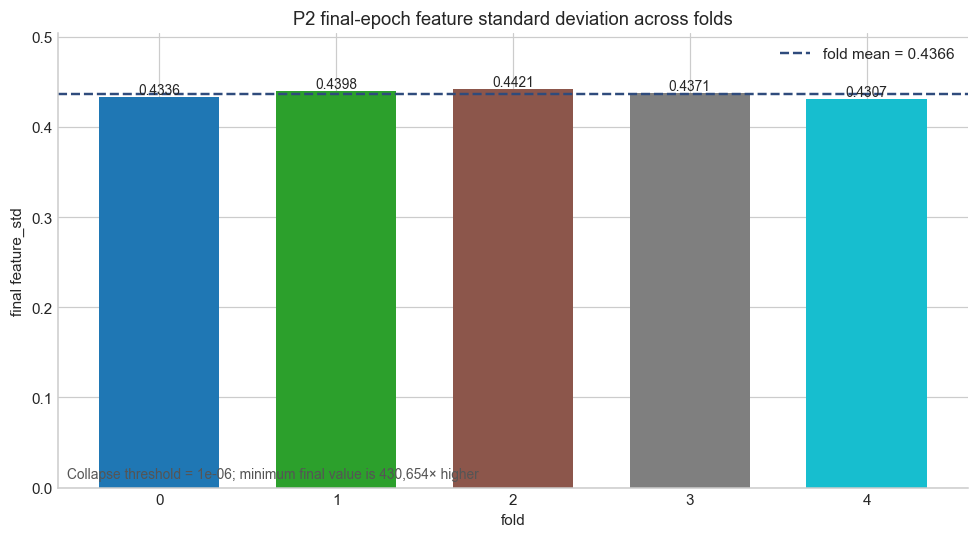

In [5]:
final_feature_std = summary.loc[folds, "final_feature_std"]
final_feature_mean = final_feature_std.mean()
figure, axis = plt.subplots(figsize=(9, 5))
bars = axis.bar([str(fold) for fold in folds], final_feature_std, color=[colors[fold] for fold in folds], width=0.68)
axis.axhline(final_feature_mean, color="#2F4B7C", linestyle="--", linewidth=1.6, label=f"fold mean = {final_feature_mean:.4f}")
for bar, value in zip(bars, final_feature_std): axis.text(bar.get_x()+bar.get_width()/2, value, f"{value:.4f}", ha="center", va="bottom", fontsize=9)
axis.set(title="P2 final-epoch feature standard deviation across folds", xlabel="fold", ylabel="final feature_std", ylim=(0, final_feature_std.max()*1.14))
axis.legend()
axis.text(0.01, 0.02, f"Collapse threshold = {FEATURE_STD_MIN:.0e}; minimum final value is {final_feature_std.min()/FEATURE_STD_MIN:,.0f}× higher", transform=axis.transAxes, fontsize=9, color="#555555")
figure.tight_layout()
plt.show()

## 4. Cross-fold training summary visual

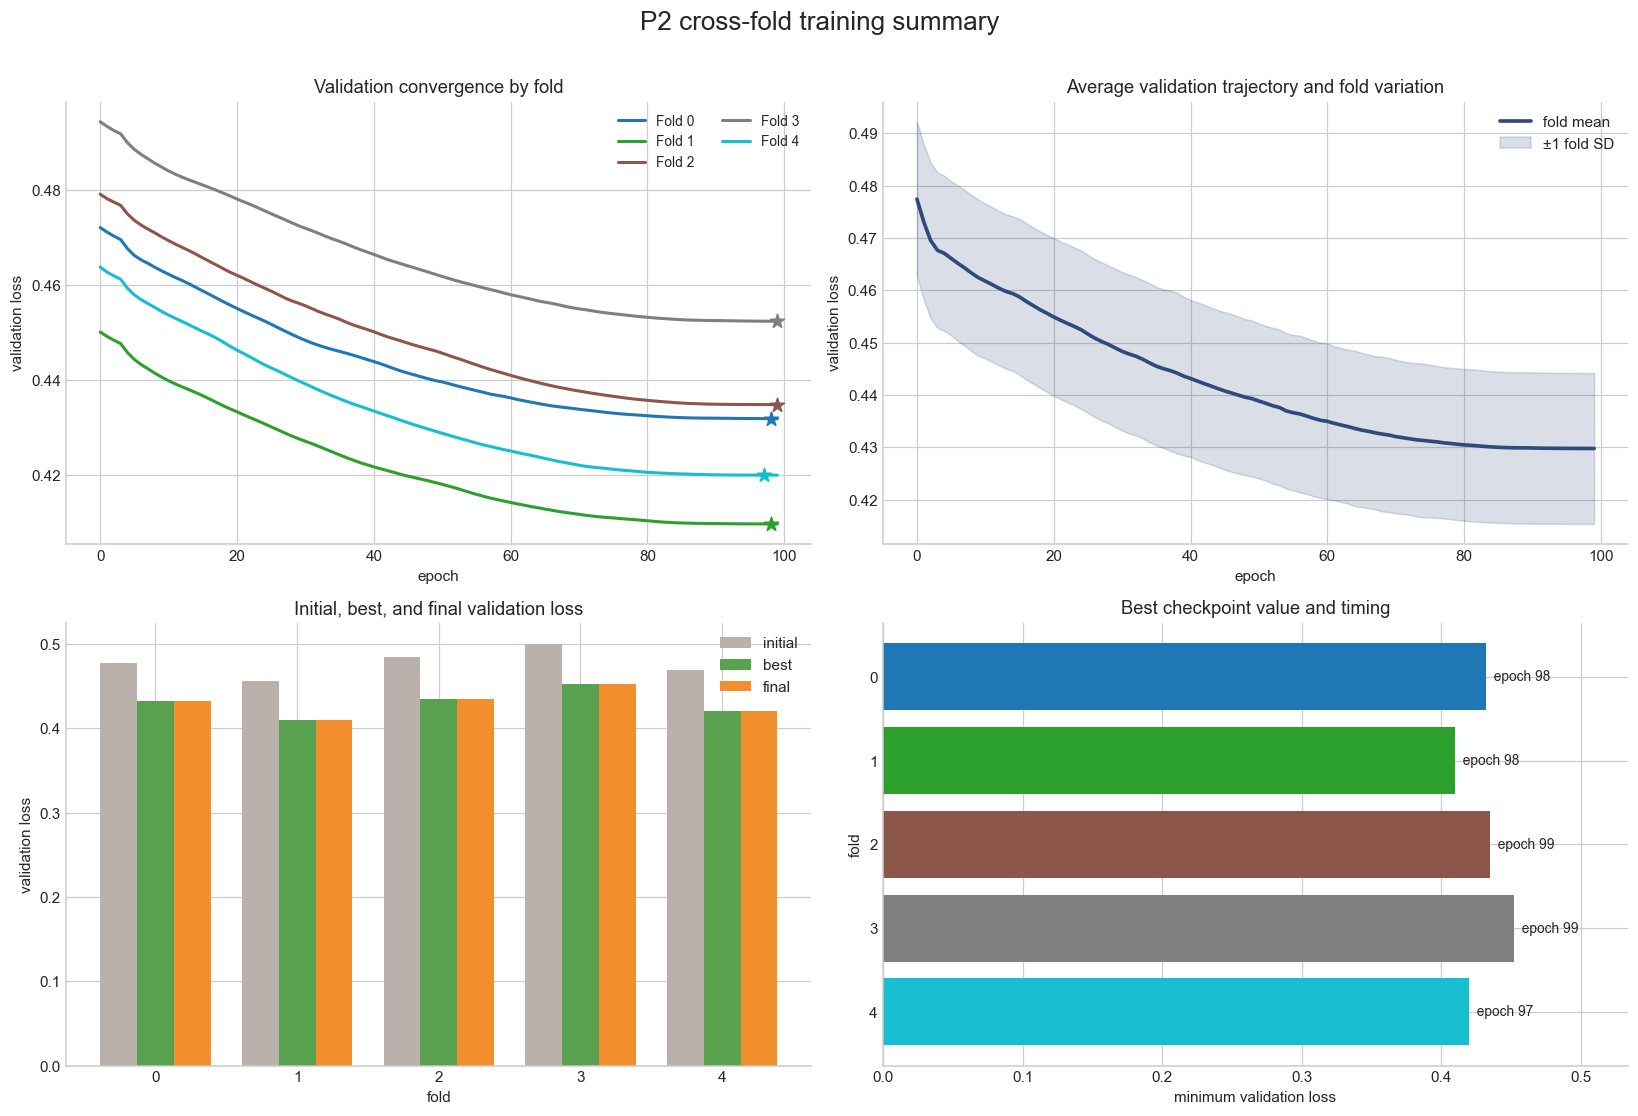

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(15, 10))
trajectory_axis, aggregate_axis, improvement_axis, checkpoint_axis = axes.ravel()
validation_wide = history.pivot(index="epoch", columns="fold", values="validation_loss").sort_index()
validation_smooth = validation_wide.rolling(ROLLING_WINDOW, center=True, min_periods=1).mean()
for fold in folds:
    trajectory_axis.plot(validation_smooth.index, validation_smooth[fold], color=colors[fold], linewidth=2, label=f"Fold {fold}")
    epoch = summary.loc[fold, "best_epoch"]
    value = history.query("fold == @fold and epoch == @epoch").validation_loss.iloc[0]
    trajectory_axis.scatter(epoch, value, color=colors[fold], marker="*", s=90)
trajectory_axis.set(title="Validation convergence by fold", xlabel="epoch", ylabel="validation loss")
trajectory_axis.legend(ncol=2, fontsize=9)
mean_curve, std_curve = validation_wide.mean(axis=1), validation_wide.std(axis=1, ddof=0)
aggregate_axis.plot(mean_curve.index, mean_curve, color="#2F4B7C", linewidth=2.4, label="fold mean")
aggregate_axis.fill_between(mean_curve.index, mean_curve-std_curve, mean_curve+std_curve, color="#2F4B7C", alpha=0.18, label="±1 fold SD")
aggregate_axis.set(title="Average validation trajectory and fold variation", xlabel="epoch", ylabel="validation loss")
aggregate_axis.legend()
x, width = np.arange(len(folds)), 0.26
improvement_axis.bar(x-width, summary.loc[folds, "initial_val_loss"], width, label="initial", color="#BAB0AC")
improvement_axis.bar(x, summary.loc[folds, "best_val_loss"], width, label="best", color="#59A14F")
improvement_axis.bar(x+width, summary.loc[folds, "final_val_loss"], width, label="final", color="#F28E2B")
improvement_axis.set(title="Initial, best, and final validation loss", xlabel="fold", ylabel="validation loss", xticks=x, xticklabels=folds)
improvement_axis.legend()
bars = checkpoint_axis.barh([str(fold) for fold in folds], summary.loc[folds, "best_val_loss"], color=[colors[fold] for fold in folds])
for bar, fold in zip(bars, folds): checkpoint_axis.text(bar.get_width(), bar.get_y()+bar.get_height()/2, f"  epoch {summary.loc[fold, 'best_epoch']:.0f}", va="center", fontsize=9)
checkpoint_axis.invert_yaxis()
checkpoint_axis.set(title="Best checkpoint value and timing", xlabel="minimum validation loss", ylabel="fold")
checkpoint_axis.set_xlim(right=summary.best_val_loss.max()*1.18)
figure.suptitle("P2 cross-fold training summary", fontsize=17, y=1.01)
figure.tight_layout()
plt.show()

## 5. Automated reading of P2 optimization

In [7]:
optimization_lines = [
    "### What the histories show",
    f"- All {len(folds)} folds improved over epoch 0; best-validation improvement ranged from **{summary.improvement_pct.min():.1f}% to {summary.improvement_pct.max():.1f}%**.",
    f"- Best checkpoints occurred between epochs **{summary.best_epoch.min():.0f} and {summary.best_epoch.max():.0f}**, within the final three epochs in every fold.",
    f"- Cross-view reconstruction contributed **{summary.cross_share_pct.mean():.1f}%** of total training loss on average.",
    f"- Final feature standard deviation ranged from **{summary.final_feature_std.min():.4f} to {summary.final_feature_std.max():.4f}**; no history approached collapse.",
    "", "### Interpretation limit",
    "- Optimization and non-collapse do not establish that P2 preserved useful anatomy. The independent audit below tests that claim directly.",
]
display(Markdown("\n".join(optimization_lines)))

### What the histories show
- All 5 folds improved over epoch 0; best-validation improvement ranged from **9.5% to 10.5%**.
- Best checkpoints occurred between epochs **97 and 99**, within the final three epochs in every fold.
- Cross-view reconstruction contributed **60.5%** of total training loss on average.
- Final feature standard deviation ranged from **0.4307 to 0.4421**; no history approached collapse.

### Interpretation limit
- Optimization and non-collapse do not establish that P2 preserved useful anatomy. The independent audit below tests that claim directly.

## 6. Independent P1 → P2 frozen-encoder audit

P1 is the direct input to P2, so this comparison isolates what cross-view training changed. Each connected pair represents the same fold. A quality WARN is reported evidence; a structural failure would invalidate the audit.

In [8]:
AUDIT_ROOT = PROJECT_ROOT / "HPC" / "HPC_results" / "feature_audit"
AUDIT_STAGES = ("p1", "p2")
STAGE_LABELS = {"p1": "P1", "p2": "P2"}
STAGE_COLORS = {"p1": "#9C9C9C", "p2": "#4C78A8"}
audit_rows = []
for fold in folds:
    for order, stage in enumerate(AUDIT_STAGES):
        path = AUDIT_ROOT / f"fold{fold}" / stage / "feature_audit_summary.json"
        if not path.is_file(): raise FileNotFoundError(f"Missing audit summary: {path}")
        payload = json.loads(path.read_text(encoding="utf-8"))
        if payload.get("schema_version") != "encoder_feature_audit_v1" or int(payload.get("fold", -1)) != int(fold): raise ValueError(f"Audit mismatch: {path}")
        if payload.get("structural_status") != "PASS" or payload.get("encoder_unchanged") is not True or payload.get("test_paths_opened") is not False: raise RuntimeError(f"Fold {fold} {stage} violates the structural contract")
        probes = payload["local"]["probes"]
        best_level = max(probes, key=lambda level: probes[level]["validation_macro_dice"])
        row = {
            "fold": int(fold), "stage": stage, "stage_order": order, "stage_label": STAGE_LABELS[stage],
            "quality_status": payload["quality_status"], "local_status": payload["local"]["status"],
            "global_status": payload["global"]["status"], "warnings": ", ".join(payload.get("warnings", [])) or "none",
            "preservation_status": payload["p2_preservation"].get("status", "NOT_APPLICABLE"),
            "best_local_dice": probes[best_level]["validation_macro_dice"], "atlas_dice": probes[best_level]["atlas_macro_dice"],
            "mrr": payload["global"]["mrr"], "recall_at_1": payload["global"]["recall_at_1"],
            "paired_cosine_margin": payload["global"]["paired_cosine_margin"],
        }
        for level in ("L0", "L1", "L2", "L3"):
            row[f"effective_rank_{level}"] = payload["feature_statistics"][level]["effective_rank"]
        audit_rows.append(row)
audit = pd.DataFrame(audit_rows).sort_values(["fold", "stage_order"]).drop(columns="stage_order").reset_index(drop=True)
display(audit[["fold", "stage_label", "quality_status", "local_status", "global_status", "preservation_status", "warnings"]])
metrics = ["best_local_dice", "mrr", "recall_at_1", "paired_cosine_margin"]
wide = audit.pivot(index="fold", columns="stage", values=metrics)
audit_delta = pd.DataFrame(index=folds)
for metric in metrics:
    audit_delta[f"{metric}_p1"] = wide[(metric, "p1")]
    audit_delta[f"{metric}_p2"] = wide[(metric, "p2")]
    audit_delta[f"{metric}_change"] = audit_delta[f"{metric}_p2"] - audit_delta[f"{metric}_p1"]
audit_delta.index.name = "fold"
change_columns = [column for column in audit_delta if column.endswith("_change")]
styled_delta = audit_delta.style.format("{:.4f}")
for column in change_columns:
    limit = audit_delta[column].abs().max()
    styled_delta = styled_delta.background_gradient(subset=[column], cmap="RdYlGn", vmin=-limit, vmax=limit)
display(styled_delta)

,fold,stage_label,quality_status,local_status,global_status,preservation_status,warnings
0,0,P1,WARN,PASS,PASS,NOT_APPLICABLE,reference_comparison_incomplete
1,0,P2,WARN,PASS,PASS,WARN,p2_preservation_warning
2,1,P1,WARN,PASS,PASS,NOT_APPLICABLE,reference_comparison_incomplete
3,1,P2,PASS,PASS,PASS,PASS,none
4,2,P1,WARN,PASS,WARN,NOT_APPLICABLE,"reference_comparison_incomplete, global_featur..."
5,2,P2,PASS,PASS,PASS,PASS,none
6,3,P1,WARN,PASS,PASS,NOT_APPLICABLE,reference_comparison_incomplete
7,3,P2,WARN,PASS,PASS,WARN,p2_preservation_warning
8,4,P1,WARN,PASS,PASS,NOT_APPLICABLE,reference_comparison_incomplete
9,4,P2,WARN,PASS,WARN,WARN,"global_feature_evidence_below_threshold, p2_pr..."


,best_local_dice_p1,best_local_dice_p2,best_local_dice_change,mrr_p1,mrr_p2,mrr_change,recall_at_1_p1,recall_at_1_p2,recall_at_1_change,paired_cosine_margin_p1,paired_cosine_margin_p2,paired_cosine_margin_change
fold,,,,,,,,,,,,
0,0.6377,0.6425,0.0048,0.5156,0.5085,-0.0071,0.3214,0.2857,-0.0357,0.0026,0.0025,-0.0002
1,0.6576,0.6592,0.0015,0.3660,0.3841,0.0180,0.1429,0.2143,0.0714,0.0170,0.0019,-0.0150
2,0.6448,0.6470,0.0022,0.2532,0.4549,0.2018,0.0714,0.2500,0.1786,0.0005,0.0027,0.0023
3,0.6491,0.6570,0.0079,0.3642,0.3606,-0.0036,0.1786,0.2143,0.0357,0.0016,0.0035,0.0018
4,0.6552,0.6662,0.0110,0.3620,0.2103,-0.1517,0.1667,0.0667,-0.1000,0.0021,-0.0028,-0.0049


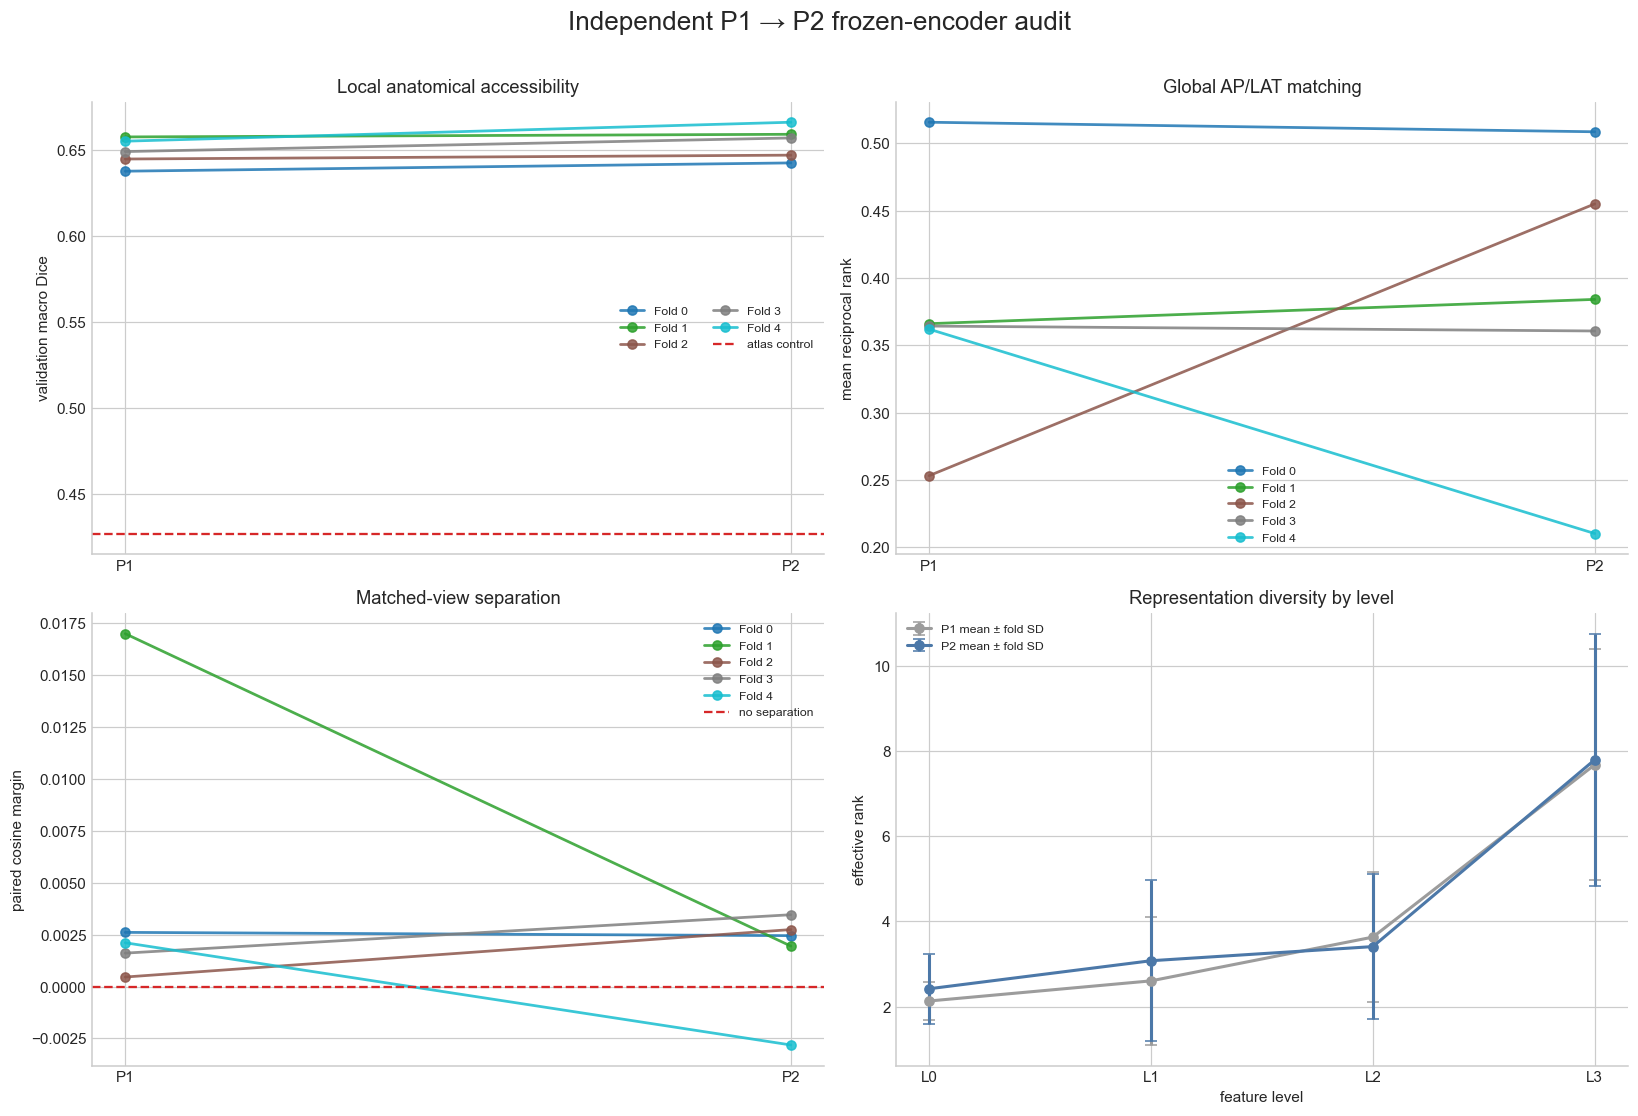

In [9]:
figure, axes = plt.subplots(2, 2, figsize=(15, 10))
local_axis, retrieval_axis, margin_axis, rank_axis = axes.ravel()
def paired_stage_plot(axis, metric, title, ylabel, baseline=None):
    for fold in folds:
        values = [audit.query("fold == @fold and stage == @stage")[metric].iloc[0] for stage in AUDIT_STAGES]
        axis.plot([0, 1], values, color=colors[fold], marker="o", linewidth=1.8, alpha=0.85, label=f"Fold {fold}")
    if baseline is not None: axis.axhline(baseline, color="#D62728", linestyle="--", label="atlas control")
    axis.set(title=title, ylabel=ylabel, xticks=[0, 1], xticklabels=[STAGE_LABELS[s] for s in AUDIT_STAGES])
paired_stage_plot(local_axis, "best_local_dice", "Local anatomical accessibility", "validation macro Dice", audit.query("stage == 'p2'").atlas_dice.mean())
local_axis.legend(ncol=2, fontsize=8)
paired_stage_plot(retrieval_axis, "mrr", "Global AP/LAT matching", "mean reciprocal rank")
retrieval_axis.legend(fontsize=8)
paired_stage_plot(margin_axis, "paired_cosine_margin", "Matched-view separation", "paired cosine margin")
margin_axis.axhline(0, color="#D62728", linestyle="--", label="no separation")
margin_axis.legend(fontsize=8)
levels, level_x = ["L0", "L1", "L2", "L3"], np.arange(4)
for stage in AUDIT_STAGES:
    stage_data = audit.query("stage == @stage")
    means = [stage_data[f"effective_rank_{level}"].mean() for level in levels]
    deviations = [stage_data[f"effective_rank_{level}"].std(ddof=0) for level in levels]
    rank_axis.errorbar(level_x, means, yerr=deviations, marker="o", capsize=4, linewidth=2, color=STAGE_COLORS[stage], label=f"{STAGE_LABELS[stage]} mean ± fold SD")
rank_axis.set(title="Representation diversity by level", xlabel="feature level", ylabel="effective rank", xticks=level_x, xticklabels=levels)
rank_axis.legend(fontsize=8)
figure.suptitle("Independent P1 → P2 frozen-encoder audit", fontsize=17, y=1.01)
figure.tight_layout()
plt.show()

## 7. Automated P2 audit interpretation

In [10]:
p2_audit = audit.query("stage == 'p2'").set_index("fold")
local_improved = audit_delta.index[audit_delta.best_local_dice_change > 0].tolist()
mrr_improved = audit_delta.index[audit_delta.mrr_change > 0].tolist()
margin_improved = audit_delta.index[audit_delta.paired_cosine_margin_change > 0].tolist()
positive_margin = p2_audit.index[p2_audit.paired_cosine_margin > 0].tolist()
preservation_pass = p2_audit.index[p2_audit.preservation_status == "PASS"].tolist()
warning_folds = {int(row.Index): row.warnings for row in p2_audit.itertuples() if row.warnings != "none"}
p1_l3 = audit.query("stage == 'p1'").effective_rank_L3.mean()
audit_lines = [
    "### What P2 changed",
    f"- **Structural validity:** all {len(folds)} P2 audits passed, encoders remained frozen during evaluation, and no test paths were opened.",
    f"- **Local anatomy:** probe Dice improved in {len(local_improved)}/{len(folds)} folds ({local_improved}); mean paired change **{audit_delta.best_local_dice_change.mean():+.4f}**.",
    f"- **Cross-view retrieval:** MRR improved in {len(mrr_improved)}/{len(folds)} folds ({mrr_improved}); mean paired change **{audit_delta.mrr_change.mean():+.4f}**.",
    f"- **Matched-view separation:** margin improved in {len(margin_improved)}/{len(folds)} folds ({margin_improved}) and remained positive in folds {positive_margin}.",
    f"- **Representation diversity:** mean L3 effective rank changed from **{p1_l3:.2f}** to **{p2_audit.effective_rank_L3.mean():.2f}**.",
    f"- **P2 preservation gate:** PASS in {len(preservation_pass)}/{len(folds)} folds ({preservation_pass}); warnings: {warning_folds}.",
    "", "### Overall interpretation",
    "- P2 optimized consistently and improved local probe performance across all folds, but global cross-view preservation is heterogeneous.",
    "- Fold-specific WARN results must remain visible—especially any fold with negative matched-view margin—rather than being hidden by the mean improvement.",
    "- This audit describes frozen features; downstream 3D reconstruction remains the decisive evaluation.",
]
display(Markdown("\n".join(audit_lines)))

### What P2 changed
- **Structural validity:** all 5 P2 audits passed, encoders remained frozen during evaluation, and no test paths were opened.
- **Local anatomy:** probe Dice improved in 5/5 folds ([0, 1, 2, 3, 4]); mean paired change **+0.0055**.
- **Cross-view retrieval:** MRR improved in 2/5 folds ([1, 2]); mean paired change **+0.0115**.
- **Matched-view separation:** margin improved in 2/5 folds ([2, 3]) and remained positive in folds [0, 1, 2, 3].
- **Representation diversity:** mean L3 effective rank changed from **7.69** to **7.80**.
- **P2 preservation gate:** PASS in 2/5 folds ([1, 2]); warnings: {0: 'p2_preservation_warning', 3: 'p2_preservation_warning', 4: 'global_feature_evidence_below_threshold, p2_preservation_warning'}.

### Overall interpretation
- P2 optimized consistently and improved local probe performance across all folds, but global cross-view preservation is heterogeneous.
- Fold-specific WARN results must remain visible—especially any fold with negative matched-view margin—rather than being hidden by the mean improvement.
- This audit describes frozen features; downstream 3D reconstruction remains the decisive evaluation.